# Installation & Setup

In [7]:
# Install TensorFlow
%pip install tensorflow # For GPU support
%pip install keras

# Verification
import tensorflow as tf


  Using cached termcolor-3.2.0-py3-none-any.whl.metadata (6.4 kB)
  Using cached markupsafe-3.0.3-cp311-cp311-macosx_11_0_arm64.whl.metadata (2.7 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 MB 2.1 MB/s  0:01:34m0:00:0100:03
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 2.4 MB/s  0:00:05 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 2.2 MB/s  0:00:02 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 2.3 MB/s  0:00:11m0:00:0100:01
Using cached termcolor-3.2.0-py3-none-any.whl (7.7 kB)
Using cached markupsafe-3.0.3-cp311-cp311-macosx_11_0_arm64.whl (12 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16/16 [tensorflow]6 [tensorflow]]
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


/opt/homebrew/lib/python3.11/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


# DEEP LEARNING FUNDAMENTALS

## Perceptron

Perceptron (1957): Basic unit of neural networks
   y = activation(w·x + b)

<img src="/Users/hadilsahraoui/Downloads/deep-learning-keras-tensorflow-master/imgs/Perceptron.png" width="45%">

In [ ]:
<img src="/Users/hadilsahraoui/Downloads/deep-learning-keras-tensorflow-master/imgs/MLP.png" width="45%">

## Forward Propagation

In [ ]:
<img src="/Users/hadilsahraoui/Downloads/deep-learning-keras-tensorflow-master/imgs/fwd_step_net.png" width="50%" />

_(Source: Python Machine Learning, S. Raschka)_

## Activation Functions

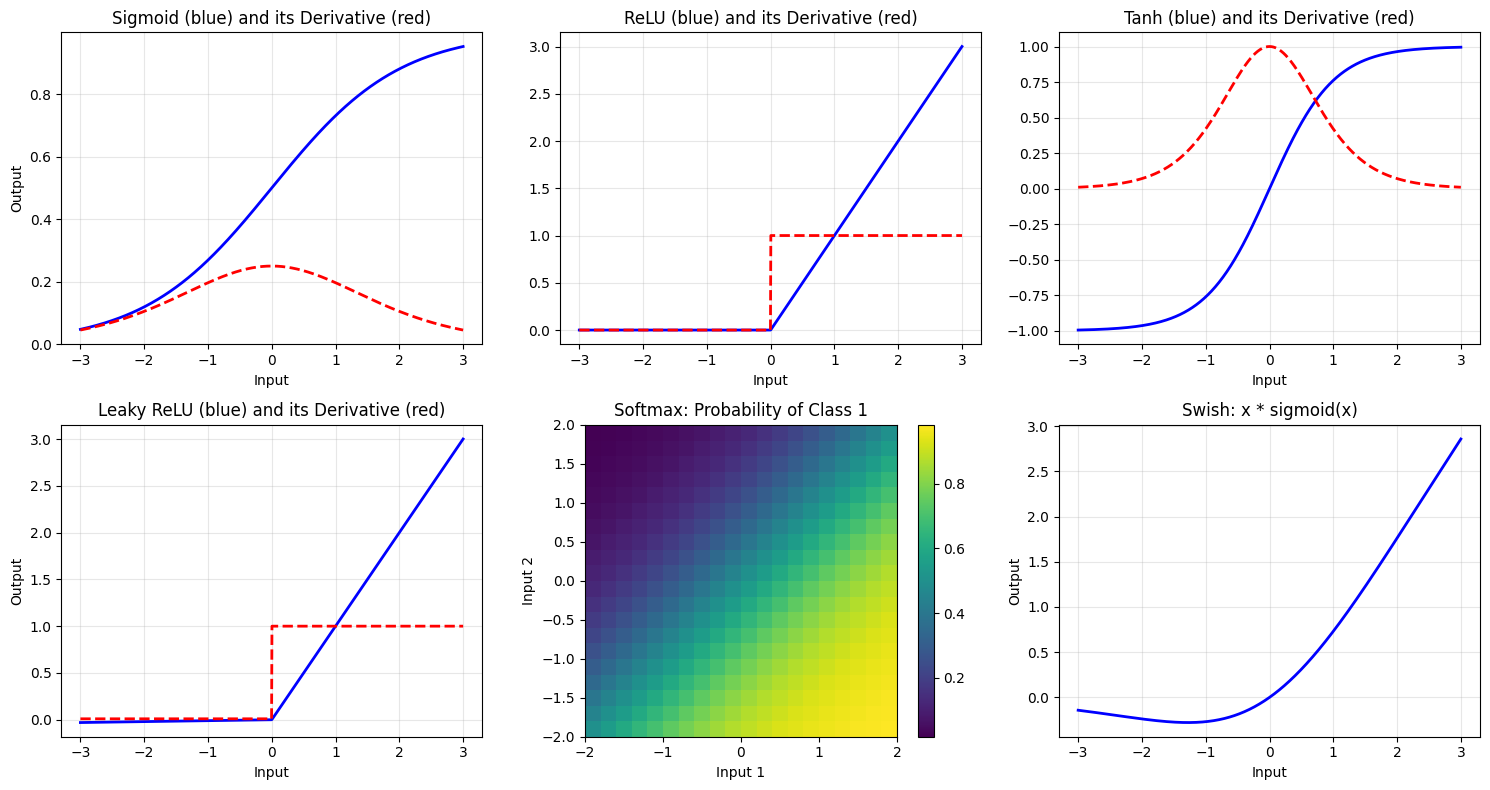

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

class ActivationFunctions:
    """A collection of common activation functions used in neural networks."""
    
    @staticmethod
    def sigmoid(x):
        """Sigmoid activation function."""
        return 1 / (1 + np.exp(-x))
    
    @staticmethod
    def sigmoid_derivative(x):
        """Derivative of sigmoid function."""
        s = ActivationFunctions.sigmoid(x)
        return s * (1 - s)
    
    @staticmethod
    def relu(x):
        """ReLU activation function."""
        return np.maximum(0, x)
    
    @staticmethod
    def relu_derivative(x):
        """Derivative of ReLU function."""
        return (x > 0).astype(float)
    
    @staticmethod
    def tanh(x):
        """Hyperbolic tangent activation function."""
        return np.tanh(x)
    
    @staticmethod
    def tanh_derivative(x):
        """Derivative of tanh function."""
        return 1 - np.tanh(x) ** 2
    
    @staticmethod
    def leaky_relu(x, alpha=0.01):
        """Leaky ReLU activation function."""
        return np.where(x > 0, x, alpha * x)
    
    @staticmethod
    def leaky_relu_derivative(x, alpha=0.01):
        """Derivative of Leaky ReLU function."""
        dx = np.ones_like(x)
        dx[x < 0] = alpha
        return dx
    
    @staticmethod
    def softmax(x):
        """Softmax activation function."""
        # Numerical stability: subtract max
        exp_x = np.exp(x - np.max(x, axis=-1, keepdims=True))
        return exp_x / np.sum(exp_x, axis=-1, keepdims=True)
    
    @staticmethod
    def plot_activations():
        """Plot all activation functions and their derivatives."""
        x = np.linspace(-3, 3, 1000)
        fig, axes = plt.subplots(2, 3, figsize=(15, 8))
        
        # Sigmoid
        axes[0, 0].plot(x, ActivationFunctions.sigmoid(x), 'b-', linewidth=2)
        axes[0, 0].plot(x, ActivationFunctions.sigmoid_derivative(x), 'r--', linewidth=2)
        axes[0, 0].set_title('Sigmoid (blue) and its Derivative (red)')
        axes[0, 0].grid(True, alpha=0.3)
        axes[0, 0].set_xlabel('Input')
        axes[0, 0].set_ylabel('Output')
        
        # ReLU
        axes[0, 1].plot(x, ActivationFunctions.relu(x), 'b-', linewidth=2)
        axes[0, 1].plot(x, ActivationFunctions.relu_derivative(x), 'r--', linewidth=2)
        axes[0, 1].set_title('ReLU (blue) and its Derivative (red)')
        axes[0, 1].grid(True, alpha=0.3)
        axes[0, 1].set_xlabel('Input')
        
        # Tanh
        axes[0, 2].plot(x, ActivationFunctions.tanh(x), 'b-', linewidth=2)
        axes[0, 2].plot(x, ActivationFunctions.tanh_derivative(x), 'r--', linewidth=2)
        axes[0, 2].set_title('Tanh (blue) and its Derivative (red)')
        axes[0, 2].grid(True, alpha=0.3)
        axes[0, 2].set_xlabel('Input')
        
        # Leaky ReLU
        axes[1, 0].plot(x, ActivationFunctions.leaky_relu(x), 'b-', linewidth=2)
        axes[1, 0].plot(x, ActivationFunctions.leaky_relu_derivative(x), 'r--', linewidth=2)
        axes[1, 0].set_title('Leaky ReLU (blue) and its Derivative (red)')
        axes[1, 0].grid(True, alpha=0.3)
        axes[1, 0].set_xlabel('Input')
        axes[1, 0].set_ylabel('Output')
        
        # Softmax visualization
        x1 = np.linspace(-2, 2, 20)
        x2 = np.linspace(-2, 2, 20)
        X1, X2 = np.meshgrid(x1, x2)
        X = np.stack([X1.flatten(), X2.flatten()], axis=1)
        softmax_output = ActivationFunctions.softmax(X)
        prob_class1 = softmax_output[:, 0].reshape(X1.shape)
        
        im = axes[1, 1].imshow(prob_class1, extent=[-2, 2, -2, 2], 
                              origin='lower', cmap='viridis')
        axes[1, 1].set_title('Softmax: Probability of Class 1')
        axes[1, 1].set_xlabel('Input 1')
        axes[1, 1].set_ylabel('Input 2')
        plt.colorbar(im, ax=axes[1, 1])
        
        # Swish activation
        axes[1, 2].plot(x, x * ActivationFunctions.sigmoid(x), 'b-', linewidth=2)
        axes[1, 2].set_title('Swish: x * sigmoid(x)')
        axes[1, 2].grid(True, alpha=0.3)
        axes[1, 2].set_xlabel('Input')
        axes[1, 2].set_ylabel('Output')
        
        plt.tight_layout()
        plt.show()

# Plot activation functions
ActivationFunctions.plot_activations()

   - MSE: (y_pred - y_true)² - Regression
   - Cross-Entropy: -∑ y_true·log(y_pred) - Classification
   - Binary Cross-Entropy: For binary classification

## Backpropagation Algorithm

∂L/∂w = ∂L/∂a * ∂a/∂z * ∂z/∂w

In [ ]:
<img src="/Users/hadilsahraoui/Downloads/deep-learning-keras-tensorflow-master/imgs/bkwd_step_net.png" width="50%" />

_(Source: Python Machine Learning, S. Raschka)_

XOR Problem:
X =  [[0 0]
 [0 1]
 [1 0]
 [1 1]]
y =  [[0]
 [1]
 [1]
 [0]]

Predictions:
Input: [0 0], True: 0, Predicted: 0, Probabilities: [0.957 0.043]
Input: [0 1], True: 1, Predicted: 1, Probabilities: [0.014 0.986]
Input: [1 0], True: 1, Predicted: 1, Probabilities: [0.01 0.99]
Input: [1 1], True: 0, Predicted: 0, Probabilities: [0.992 0.008]

Accuracy: 100.00%


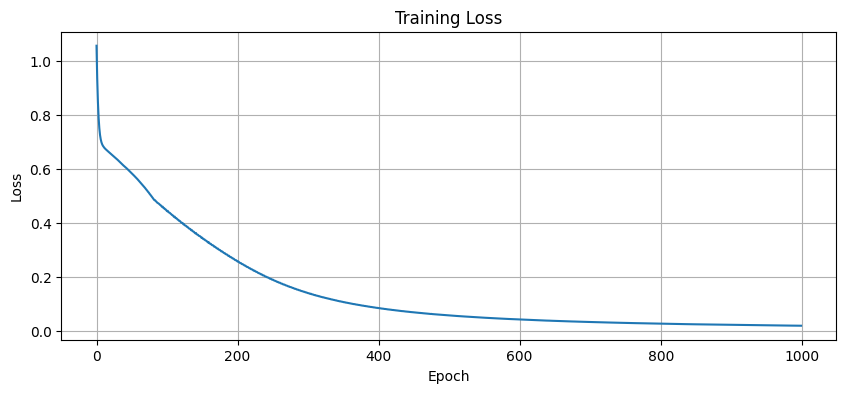

In [ ]:
# Example usage: Solving the XOR problem
if __name__ == "__main__":
    # Generate synthetic dataset
    np.random.seed(42)
    
    # XOR problem (non-linearly separable)
    X = np.array([[0, 0, 1, 1],
                  [0, 1, 0, 1]])
    y = np.array([[0, 1, 1, 0]])  # XOR output
    
    # One-hot encode for classification
    y_onehot = np.zeros((2, 4))
    y_onehot[0, y[0] == 0] = 1
    y_onehot[1, y[0] == 1] = 1
    
    print("XOR Problem:")
    print("X = ", X.T)
    print("y = ", y.T)
    
    # Create and train neural network
    nn = NeuralNetwork(
        layer_sizes=[2, 4, 2],  # Input: 2, Hidden: 4, Output: 2
        activations=['relu', 'softmax'],  # Hidden: ReLU, Output: Softmax
        learning_rate=0.1
    )
    
    # Train
    train_losses, _ = nn.train(
        X_train=X,
        y_train=y_onehot,
        epochs=1000,
        batch_size=4,
        verbose=False
    )
    
    # Predict
    predictions = nn.predict(X)
    predicted_classes = np.argmax(predictions, axis=0)
    
    print("\nPredictions:")
    for i in range(X.shape[1]):
        print(f"Input: {X[:,i]}, True: {y[0,i]}, Predicted: {predicted_classes[i]}, "
              f"Probabilities: {predictions[:,i].round(3)}")
    
    print(f"\nAccuracy: {nn.accuracy(X, y_onehot):.2%}")
    
    # Plot training loss
    plt.figure(figsize=(10, 4))
    plt.plot(train_losses)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Loss')
    plt.grid(True)
    plt.show()

## Optimizers

   - SGD: θ = θ - η∇θJ(θ)
   - Momentum: Adds velocity term
   - RMSprop: Adaptive learning rates
   - Adam: Combines Momentum + RMSprop (Most popular)

In [ ]:
class NeuralNetMath:
    """Mathematical implementation of neural network operations"""
    
    @staticmethod
    def forward_pass(X, W1, b1, W2, b2):
        """Two-layer neural network forward pass"""
        # Layer 1
        Z1 = np.dot(X, W1) + b1
        A1 = np.maximum(0, Z1)  # ReLU
        
        # Layer 2
        Z2 = np.dot(A1, W2) + b2
        A2 = 1 / (1 + np.exp(-Z2))  # Sigmoid
        
        return A2, (Z1, A1, Z2, A2)
    
    @staticmethod
    def backward_pass(X, y, cache, W1, W2):
        """Backpropagation implementation"""
        Z1, A1, Z2, A2 = cache
        m = X.shape[0]
        
        # Gradient calculation
        dZ2 = A2 - y
        dW2 = np.dot(A1.T, dZ2) / m
        db2 = np.sum(dZ2, axis=0, keepdims=True) / m
        
        dA1 = np.dot(dZ2, W2.T)
        dZ1 = dA1 * (Z1 > 0)  # ReLU derivative
        dW1 = np.dot(X.T, dZ1) / m
        db1 = np.sum(dZ1, axis=0, keepdims=True) / m
        
        return dW1, db1, dW2, db2
    
    @staticmethod
    def initialize_parameters(layer_dims):
        """Xavier/Glorot initialization"""
        parameters = {}
        L = len(layer_dims)
        
        for l in range(1, L):
            parameters[f'W{l}'] = np.random.randn(
                layer_dims[l-1], layer_dims[l]) * np.sqrt(2./layer_dims[l-1])
            parameters[f'b{l}'] = np.zeros((1, layer_dims[l]))
        
        return parameters

## Regularization Techniques

L1 REGULARIZATION (LASSO):
- Adds absolute value of weights to loss: Loss = Original Loss + λ * Σ|w|
- Effect: Encourages sparsity - drives some weights to exactly zero
- Use when: Feature selection needed, many irrelevant features
- Advantages: Creates sparse models, automatic feature selection
- Disadvantages: Not differentiable at zero, can be unstable

L2 REGULARIZATION (RIDGE):
- Adds squared value of weights to loss: Loss = Original Loss + λ * Σw²
- Effect: Penalizes large weights - shrinks all weights proportionally
- Use when: Most features are relevant, want stable coefficients
- Advantages: Differentiable everywhere, stable optimization
- Disadvantages: Doesn't perform feature selection

ELASTIC NET:
- Combines L1 and L2: Loss = Original Loss + λ1 * Σ|w| + λ2 * Σw²
- Best of both worlds: Feature selection + stability
DROPOUT REGULARIZATION:
- What it does: Randomly "drop" (set to zero) neurons during training
- Why it works: Prevents co-adaptation of neurons, forces network to learn redundant representations
- Key parameters: Dropout rate (probability of dropping a neuron)
- During testing: All neurons are active, but weights are scaled by dropout rate
- Variants: SpatialDropout (for CNNs), DropConnect, Monte Carlo Dropout
BATCH NORMALIZATION (BatchNorm):
- What it does: Normalizes the activations of each layer to have zero mean and unit variance
- Why it works:
  1. Reduces internal covariate shift
  2. Allows higher learning rates
  3. Acts as a mild regularizer (due to noise from batch statistics)
  4. Reduces sensitivity to weight initialization


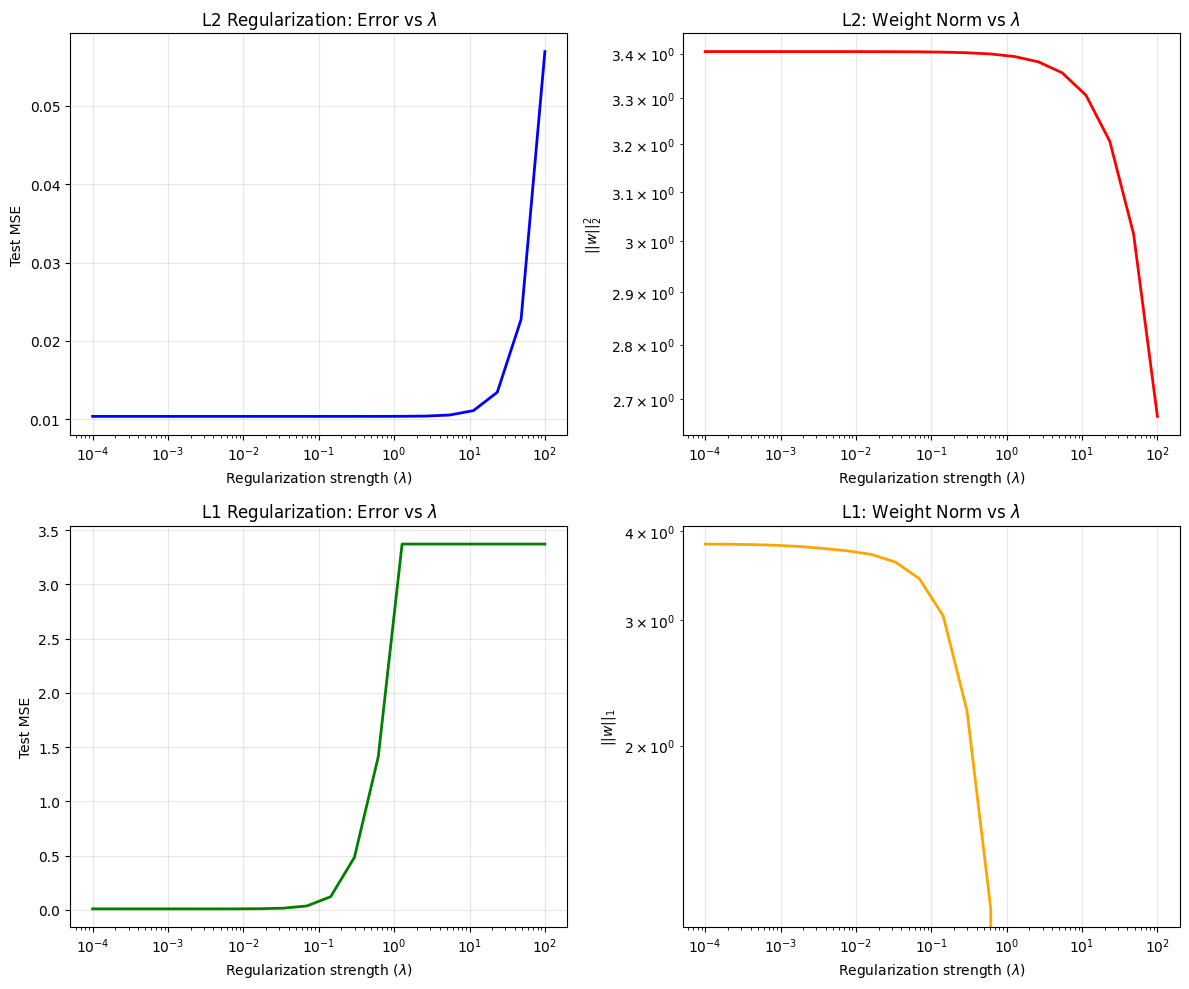

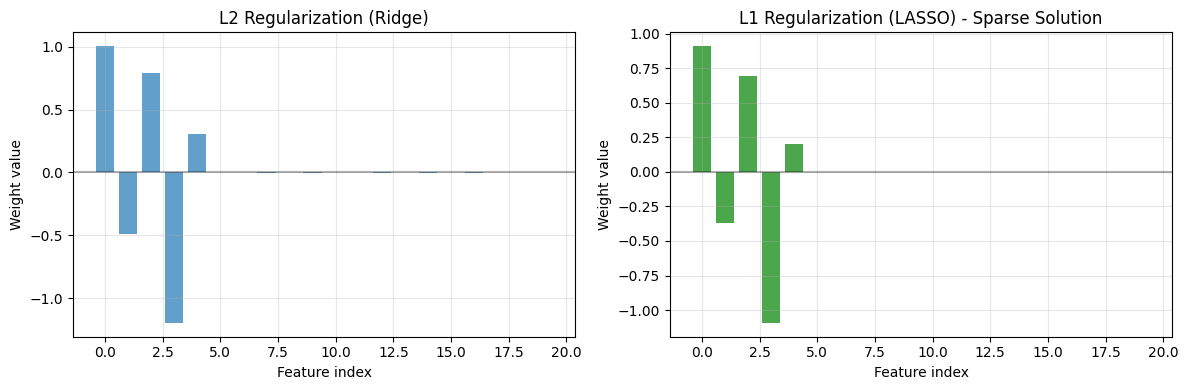

Number of non-zero weights (threshold 1e-4):
L2 (Ridge): 20/20
L1 (LASSO): 5/20
True non-zero: 5/20


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso

class Regularization:
    """Implementation of various regularization techniques."""
    
    @staticmethod
    def l2_regularization(weights, lambda_reg):
        """
        Compute L2 regularization penalty and gradient.
        
        Args:
            weights: List of weight matrices
            lambda_reg: Regularization strength
            
        Returns:
            penalty: L2 penalty value
            reg_gradients: Gradients for regularization term
        """
        penalty = 0
        reg_gradients = []
        for W in weights:
            penalty += 0.5 * lambda_reg * np.sum(W ** 2)
            reg_gradients.append(lambda_reg * W)
        return penalty, reg_gradients

    @staticmethod
    def l1_regularization(weights, lambda_reg):
        """
        Compute L1 regularization penalty and gradient.
        
        Args:
            weights: List of weight matrices
            lambda_reg: Regularization strength
            
        Returns:
            penalty: L1 penalty value
            reg_gradients: Gradients for regularization term
        """
        penalty = 0
        reg_gradients = []
        for W in weights:
            penalty += lambda_reg * np.sum(np.abs(W))
            reg_gradients.append(lambda_reg * np.sign(W))
        return penalty, reg_gradients

    @staticmethod
    def dropout_forward(X, dropout_rate, mode='train'):
        """
        Apply dropout during forward pass.
        
        Args:
            X: Input activations
            dropout_rate: Probability of dropping a neuron
            mode: 'train' or 'test'
            
        Returns:
            Output with dropout applied (and mask for backward pass)
        """
        if mode == 'train':
            # Create dropout mask
            keep_prob = 1 - dropout_rate
            mask = (np.random.rand(*X.shape) < keep_prob) / keep_prob
            return X * mask, mask
        else:
            # During test time, scale by keep probability
            return X * (1 - dropout_rate), None

    @staticmethod
    def dropout_backward(dA, mask, dropout_rate):
        """
        Apply dropout during backward pass.
        
        Args:
            dA: Gradient from next layer
            mask: Dropout mask from forward pass
            dropout_rate: Dropout rate used
            
        Returns:
            Gradient with dropout applied
        """
        if mask is not None:
            return dA * mask
        else:
            return dA * (1 - dropout_rate)

    @staticmethod
    def batch_normalization_forward(X, gamma, beta, eps=1e-8, mode='train',
                                  running_mean=None, running_var=None, momentum=0.9):
        """
        Batch normalization forward pass.
        
        Args:
            X: Input of shape (D, N) where D is dimension, N is batch size
            gamma: Scale parameter
            beta: Shift parameter
            eps: Small constant for numerical stability
            mode: 'train' or 'test'
            running_mean: Running mean for inference
            running_var: Running variance for inference
            momentum: Momentum for updating running statistics
            
        Returns:
            Normalized output, cache for backward pass
        """
        if mode == 'train':
            # Compute batch statistics
            mu = np.mean(X, axis=1, keepdims=True)  # Mean over batch
            var = np.var(X, axis=1, keepdims=True)  # Variance over batch
            
            # Normalize
            X_hat = (X - mu) / np.sqrt(var + eps)
            
            # Scale and shift
            out = gamma * X_hat + beta
            
            # Update running statistics for inference
            if running_mean is not None:
                running_mean = momentum * running_mean + (1 - momentum) * mu
                running_var = momentum * running_var + (1 - momentum) * var
                
            # Cache for backward pass
            cache = (X, X_hat, mu, var, gamma, eps)
            return out, cache, running_mean, running_var
        else:  # mode == 'test'
            # Use running statistics for inference
            X_hat = (X - running_mean) / np.sqrt(running_var + eps)
            out = gamma * X_hat + beta
            return out, None, running_mean, running_var

    @staticmethod
    def batch_normalization_backward(dout, cache):
        """
        Batch normalization backward pass.
        
        Args:
            dout: Gradient from next layer
            cache: Cache from forward pass
            
        Returns:
            Gradients for X, gamma, beta
        """
        X, X_hat, mu, var, gamma, eps = cache
        N = X.shape[1]
        
        # Gradients for scale and shift
        dgamma = np.sum(dout * X_hat, axis=1, keepdims=True)
        dbeta = np.sum(dout, axis=1, keepdims=True)
        
        # Gradient for normalized input
        dX_hat = dout * gamma
        
        # Gradient for variance
        dvar = np.sum(dX_hat * (X - mu) * -0.5 * (var + eps) ** -1.5, axis=1, keepdims=True)
        
        # Gradient for mean
        dmu = np.sum(dX_hat * -1 / np.sqrt(var + eps), axis=1, keepdims=True) + \
              dvar * np.sum(-2 * (X - mu), axis=1, keepdims=True) / N
        
        # Gradient for input
        dX = dX_hat / np.sqrt(var + eps) + \
             dvar * 2 * (X - mu) / N + \
             dmu / N
             
        return dX, dgamma, dbeta

    @staticmethod
    def early_stopping(train_losses, val_losses, patience=10):
        """
        Determine if training should stop early.
        
        Args:
            train_losses: List of training losses
            val_losses: List of validation losses
            patience: Number of epochs to wait for improvement
            
        Returns:
            True if should stop, False otherwise
        """
        if len(val_losses) < patience + 1:
            return False
            
        # Check if validation loss hasn't improved for 'patience' epochs
        best_val_loss = min(val_losses)
        recent_val_losses = val_losses[-patience:]
        
        # If no improvement in recent epochs
        if all(loss >= best_val_loss for loss in recent_val_losses):
            return True
        return False

def demonstrate_regularization():
    """Demonstrate the effect of different regularization techniques."""
    # Generate synthetic data
    np.random.seed(42)
    n_samples = 1000
    n_features = 20
    
    # True weights (sparse)
    true_weights = np.zeros(n_features)
    true_weights[:5] = [1.0, -0.5, 0.8, -1.2, 0.3]  # Only first 5 are non-zero
    
    # Generate data
    X = np.random.randn(n_samples, n_features)
    y = X @ true_weights + np.random.randn(n_samples) * 0.1
    
    # Split data
    train_size = int(0.8 * n_samples)
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]
    
    # Train linear regression with different regularization
    def train_linear_regression(X, y, lambda_reg, reg_type='l2'):
        """Train linear regression with regularization."""
        n_features = X.shape[1]
        
        # Closed-form solution with regularization
        if reg_type == 'l2':
            # Ridge regression: (X^T X + lambda I)^-1 X^T y
            A = X.T @ X + lambda_reg * np.eye(n_features)
            weights = np.linalg.solve(A, X.T @ y)
        elif reg_type == 'l1':
            # LASSO - use coordinate descent (simplified)
            model = Lasso(alpha=lambda_reg, max_iter=10000)
            model.fit(X, y)
            weights = model.coef_
            
        return weights
    
    # Test different regularization strengths
    lambda_values = np.logspace(-4, 2, 20)
    l2_weights_norms = []
    l1_weights_norms = []
    l2_test_errors = []
    l1_test_errors = []
    
    for lambda_reg in lambda_values:
        # L2 regularization
        weights_l2 = train_linear_regression(X_train, y_train, lambda_reg, 'l2')
        y_pred_l2 = X_test @ weights_l2
        error_l2 = np.mean((y_test - y_pred_l2) ** 2)
        l2_weights_norms.append(np.sum(weights_l2 ** 2))
        l2_test_errors.append(error_l2)
        
        # L1 regularization
        weights_l1 = train_linear_regression(X_train, y_train, lambda_reg, 'l1')
        y_pred_l1 = X_test @ weights_l1
        error_l1 = np.mean((y_test - y_pred_l1) ** 2)
        l1_weights_norms.append(np.sum(np.abs(weights_l1)))
        l1_test_errors.append(error_l1)
    
    # Plot results
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # L2 regularization: error vs lambda
    axes[0, 0].semilogx(lambda_values, l2_test_errors, 'b-', linewidth=2)
    axes[0, 0].set_xlabel('Regularization strength ($\lambda$)')
    axes[0, 0].set_ylabel('Test MSE')
    axes[0, 0].set_title('L2 Regularization: Error vs $\lambda$')
    axes[0, 0].grid(True, alpha=0.3)
    
    # L2 regularization: weight norm vs lambda
    axes[0, 1].loglog(lambda_values, l2_weights_norms, 'r-', linewidth=2)
    axes[0, 1].set_xlabel('Regularization strength ($\lambda$)')
    axes[0, 1].set_ylabel(r'$||w||_2^2$')
    axes[0, 1].set_title('L2: Weight Norm vs $\lambda$')
    axes[0, 1].grid(True, alpha=0.3)
    
    # L1 regularization: error vs lambda
    axes[1, 0].semilogx(lambda_values, l1_test_errors, 'g-', linewidth=2)
    axes[1, 0].set_xlabel('Regularization strength ($\lambda$)')
    axes[1, 0].set_ylabel('Test MSE')
    axes[1, 0].set_title('L1 Regularization: Error vs $\lambda$')
    axes[1, 0].grid(True, alpha=0.3)
    
    # L1 regularization: weight norm vs lambda
    axes[1, 1].loglog(lambda_values, l1_weights_norms, 'orange', linewidth=2)
    axes[1, 1].set_xlabel('Regularization strength ($\lambda$)')
    axes[1, 1].set_ylabel('$||w||_1$')
    axes[1, 1].set_title('L1: Weight Norm vs $\lambda$')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Show sparsity of L1 vs L2
    lambda_opt = 0.1
    weights_l2_opt = train_linear_regression(X_train, y_train, lambda_opt, 'l2')
    weights_l1_opt = train_linear_regression(X_train, y_train, lambda_opt, 'l1')
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    axes[0].bar(range(n_features), weights_l2_opt, alpha=0.7)
    axes[0].axhline(y=0, color='black', linestyle='-', alpha=0.3)
    axes[0].set_xlabel('Feature index')
    axes[0].set_ylabel('Weight value')
    axes[0].set_title('L2 Regularization (Ridge)')
    axes[0].grid(True, alpha=0.3)
    
    axes[1].bar(range(n_features), weights_l1_opt, alpha=0.7, color='green')
    axes[1].axhline(y=0, color='black', linestyle='-', alpha=0.3)
    axes[1].set_xlabel('Feature index')
    axes[1].set_ylabel('Weight value')
    axes[1].set_title('L1 Regularization (LASSO) - Sparse Solution')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Count non-zero weights
    n_nonzero_l2 = np.sum(np.abs(weights_l2_opt) > 1e-4)
    n_nonzero_l1 = np.sum(np.abs(weights_l1_opt) > 1e-4)
    
    print(f"Number of non-zero weights (threshold 1e-4):")
    print(f"L2 (Ridge): {n_nonzero_l2}/{n_features}")
    print(f"L1 (LASSO): {n_nonzero_l1}/{n_features}")
    print(f"True non-zero: 5/{n_features}")
    
    return {
        'l2_weights': weights_l2_opt,
        'l1_weights': weights_l1_opt,
        'true_weights': true_weights
    }

if __name__ == "__main__":
    regularization_results = demonstrate_regularization()


## Weight Initialization

Why Initialization Matters: Poor initialization can lead to vanishing/exploding gradients.

## Start Building our MLP building blocks

Note: This process will eventually result in our own Neural Networks class

In [ ]:
class NeuralNetwork:
    def __init__(self, layer_sizes, activations, learning_rate=0.01):
        """
        Initialize neural network.
        
        Args:
            layer_sizes: List of layer sizes [input_size, hidden1_size, ..., output_size]
            activations: List of activation functions for each layer
            learning_rate: Learning rate for gradient descent
        """
        self.layer_sizes = layer_sizes
        self.activations = activations
        self.learning_rate = learning_rate
        self.L = len(layer_sizes) - 1  # Number of layers (excluding input)
        
        # Initialize parameters
        self.weights = []
        self.biases = []
        
        # He initialization for ReLU, Xavier for sigmoid/tanh
        for l in range(self.L):
            fan_in = layer_sizes[l]
            fan_out = layer_sizes[l + 1]
            if activations[l] == 'relu':
                std = np.sqrt(2.0 / fan_in)  # He initialization
            else:
                std = np.sqrt(2.0 / (fan_in + fan_out))  # Xavier/Glorot initialization
                
            W = np.random.randn(fan_out, fan_in) * std
            b = np.zeros((fan_out, 1))
            self.weights.append(W)
            self.biases.append(b)
    
    def forward(self, X):
        """
        Forward propagation through the network.
        
        Args:
            X: Input data of shape (input_size, batch_size)
            
        Returns:
            A: List of activations for each layer
            Z: List of weighted sums for each layer
        """
        A = [X]  # Activations (a^0 = X)
        Z = []    # Weighted sums
        
        for l in range(self.L):
            # Linear transformation
            z = self.weights[l] @ A[-1] + self.biases[l]
            Z.append(z)
            
            # Activation function
            if self.activations[l] == 'sigmoid':
                a = 1 / (1 + np.exp(-z))
            elif self.activations[l] == 'relu':
                a = np.maximum(0, z)
            elif self.activations[l] == 'tanh':
                a = np.tanh(z)
            elif self.activations[l] == 'softmax':
                # Stable softmax
                exp_z = np.exp(z - np.max(z, axis=0, keepdims=True))
                a = exp_z / np.sum(exp_z, axis=0, keepdims=True)
            elif self.activations[l] == 'linear':
                a = z
            else:
                raise ValueError(f"Unknown activation: {self.activations[l]}")
                
            A.append(a)
            
        return A, Z
    
    def compute_loss(self, y_pred, y_true, loss_type='cross_entropy'):
        """
        Compute loss between predictions and true labels.
        
        Args:
            y_pred: Predictions
            y_true: True labels
            loss_type: Type of loss function
            
        Returns:
            Loss value
        """
        m = y_true.shape[1]  # Batch size
        
        if loss_type == 'cross_entropy':
            # For classification (with softmax output)
            # Clip predictions to avoid log(0)
            y_pred = np.clip(y_pred, 1e-12, 1 - 1e-12)
            loss = -np.sum(y_true * np.log(y_pred)) / m
        elif loss_type == 'mse':
            # For regression
            loss = np.sum((y_pred - y_true) ** 2) / (2 * m)
        elif loss_type == 'binary_cross_entropy':
            # For binary classification
            y_pred = np.clip(y_pred, 1e-12, 1 - 1e-12)
            loss = -np.sum(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred)) / m
        else:
            raise ValueError(f"Unknown loss type: {loss_type}")
            
        return loss
    
    def backward(self, X, y, A, Z, loss_type='cross_entropy'):
        """
        Backward propagation to compute gradients.
        
        Args:
            X: Input data
            y: True labels
            A: List of activations from forward pass
            Z: List of weighted sums from forward pass
            loss_type: Type of loss function
            
        Returns:
            Gradients for weights and biases
        """
        m = X.shape[1]  # Batch size
        grads_W = []
        grads_b = []
        
        # Initialize gradients
        dA = [None] * (self.L + 1)  # Gradients for activations
        dZ = [None] * self.L       # Gradients for weighted sums
        
        # Output layer gradient
        if loss_type == 'cross_entropy' and self.activations[-1] == 'softmax':
            # Special case: softmax + cross-entropy gradient simplifies
            dA[-1] = A[-1] - y
        else:
            # General case: compute gradient through loss function
            if loss_type == 'cross_entropy':
                dL_dy_pred = -y / np.clip(A[-1], 1e-12, 1 - 1e-12)
            elif loss_type == 'mse':
                dL_dy_pred = A[-1] - y
            elif loss_type == 'binary_cross_entropy':
                dL_dy_pred = (A[-1] - y) / np.clip(A[-1] * (1 - A[-1]), 1e-12, 1 - 1e-12)
            
            # Activation derivative
            if self.activations[-1] == 'sigmoid':
                dA_dZ = A[-1] * (1 - A[-1])
            elif self.activations[-1] == 'relu':
                dA_dZ = (Z[-1] > 0).astype(float)
            elif self.activations[-1] == 'tanh':
                dA_dZ = 1 - A[-1]**2
            elif self.activations[-1] == 'linear':
                dA_dZ = 1
            else:
                raise ValueError(f"Unknown activation: {self.activations[-1]}")
                
            dA[-1] = dL_dy_pred * dA_dZ
        
        # Backpropagate through layers
        for l in reversed(range(self.L)):
            # Gradient for weighted sum
            dZ[l] = dA[l + 1]
            
            # Gradients for parameters
            grad_W = (dZ[l] @ A[l].T) / m
            grad_b = np.sum(dZ[l], axis=1, keepdims=True) / m
            grads_W.insert(0, grad_W)
            grads_b.insert(0, grad_b)
            
            # Gradient for previous layer's activation
            if l > 0:
                # Activation derivative for hidden layer
                if self.activations[l-1] == 'sigmoid':
                    dA_dZ_prev = A[l] * (1 - A[l])
                elif self.activations[l-1] == 'relu':
                    dA_dZ_prev = (Z[l-1] > 0).astype(float)
                elif self.activations[l-1] == 'tanh':
                    dA_dZ_prev = 1 - A[l]**2
                elif self.activations[l-1] == 'linear':
                    dA_dZ_prev = 1
                else:
                    raise ValueError(f"Unknown activation: {self.activations[l-1]}")
                
                # Backpropagate to previous layer
                dA[l] = (self.weights[l].T @ dZ[l]) * dA_dZ_prev
                
        return grads_W, grads_b
    
    def update_parameters(self, grads_W, grads_b):
        """
        Update network parameters using gradients.
        
        Args:
            grads_W: Gradients for weights
            grads_b: Gradients for biases
        """
        for l in range(self.L):
            self.weights[l] -= self.learning_rate * grads_W[l]
            self.biases[l] -= self.learning_rate * grads_b[l]
    
    def train(self, X_train, y_train, X_val=None, y_val=None, 
              epochs=100, batch_size=32, verbose=True):
        """
        Train the neural network.
        
        Args:
            X_train: Training data
            y_train: Training labels
            X_val: Validation data (optional)
            y_val: Validation labels (optional)
            epochs: Number of training epochs
            batch_size: Batch size for mini-batch gradient descent
            verbose: Whether to print progress
            
        Returns:
            train_losses: List of training losses
            val_losses: List of validation losses (if validation data provided)
        """
        n_samples = X_train.shape[1]
        train_losses = []
        val_losses = []
        
        for epoch in range(epochs):
            # Shuffle data
            permutation = np.random.permutation(n_samples)
            X_shuffled = X_train[:, permutation]
            y_shuffled = y_train[:, permutation]
            epoch_loss = 0
            
            # Mini-batch training
            for i in range(0, n_samples, batch_size):
                X_batch = X_shuffled[:, i:i + batch_size]
                y_batch = y_shuffled[:, i:i + batch_size]
                
                # Forward pass
                A, Z = self.forward(X_batch)
                
                # Compute loss
                batch_loss = self.compute_loss(A[-1], y_batch, 'cross_entropy')
                epoch_loss += batch_loss * X_batch.shape[1]
                
                # Backward pass
                grads_W, grads_b = self.backward(X_batch, y_batch, A, Z, 'cross_entropy')
                
                # Update parameters
                self.update_parameters(grads_W, grads_b)
            
            # Average loss for epoch
            epoch_loss /= n_samples
            train_losses.append(epoch_loss)
            
            # Validation loss
            if X_val is not None and y_val is not None:
                A_val, _ = self.forward(X_val)
                val_loss = self.compute_loss(A_val[-1], y_val, 'cross_entropy')
                val_losses.append(val_loss)
            
            # Print progress
            if verbose and (epoch + 1) % 10 == 0:
                if X_val is not None:
                    print(f"Epoch {epoch+1}/{epochs}, Train Loss: {epoch_loss:.4f}, Val Loss: {val_loss:.4f}")
                else:
                    print(f"Epoch {epoch+1}/{epochs}, Train Loss: {epoch_loss:.4f}")
                    
        return train_losses, val_losses
    
    def predict(self, X):
        """
        Make predictions for input data.
        
        Args:
            X: Input data
            
        Returns:
            Predictions
        """
        A, _ = self.forward(X)
        return A[-1]
    
    def accuracy(self, X, y):
        """
        Compute accuracy for classification.
        
        Args:
            X: Input data
            y: True labels (one-hot encoded)
            
        Returns:
            Accuracy
        """
        predictions = self.predict(X)
        predicted_classes = np.argmax(predictions, axis=0)
        true_classes = np.argmax(y, axis=0)
        accuracy = np.mean(predicted_classes == true_classes)
        return accuracy

# Tensor Fundamentals

In [ ]:
# First, let's install TensorFlow if needed
# !pip install tensorflow

import tensorflow as tf
import numpy as np
print(f"TensorFlow Version: {tf.__version__}")

In [ ]:
# Creating tensors
scalar = tf.constant(7)                # 0-dim tensor
vector = tf.constant([1, 2, 3])        # 1-dim tensor
matrix = tf.constant([[1, 2], [3, 4]]) # 2-dim tensor
tensor = tf.constant([[[1, 2], [3, 4]], [[5, 6], [7, 8]]])  # 3-dim tensor

print(f"Scalar: {scalar}")
print(f"Shape: {scalar.shape}, Dtype: {scalar.dtype}")
print(f"Matrix shape: {matrix.shape}")

# Operations
a = tf.constant([[1, 2], [3, 4]])
b = tf.constant([[5, 6], [7, 8]])

# Element-wise operations
add = tf.add(a, b)
multiply = tf.multiply(a, b)
matmul = tf.matmul(a, b)

print(f"Addition:\n{add}")
print(f"Matrix multiplication:\n{matmul}")

In [ ]:
# Variables (mutable tensors)
weights = tf.Variable(tf.random.normal([3, 2]))
bias = tf.Variable(tf.zeros([2]))

print(f"Weights:\n{weights}")
print(f"Bias: {bias}")

# Update variable
weights.assign_add(tf.ones([3, 2]))
print(f"Updated weights:\n{weights}")

In [ ]:
from tensorflow.keras import layers, models

# Sequential API (easiest)
model = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(784,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.summary()

In [ ]:
# Variables are used for trainable parameters
weight = tf.Variable(initial_value=3.0)
bias = tf.Variable(initial_value=2.0)


In [ ]:
#Automatic Differentiation with GradientTape
x = tf.Variable(3.0)
with tf.GradientTape() as tape:
    y = x**2
dy_dx = tape.gradient(y, x)  # dy/dx = 2x = 6.0

In [ ]:
# Building a Simple Model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation='relu', input_shape=(4,)),
    tf.keras.layers.Dense(3, activation='softmax')
])

In [ ]:
# Compiling the Model
model.compile(optimizer='adam',# we can use 'sgd' or 'adam' or 'rmsprop'
              loss='sparse_categorical_crossentropy',# we can use 'mse' or 'binary_crossentropy',
              metrics=['accuracy'])

In [ ]:
# Create a dataset from numpy arrays
import numpy as np
features = np.random.random((1000, 4))
labels = np.random.randint(0, 3, (1000, 1))
dataset = tf.data.Dataset.from_tensor_slices((features, labels))
dataset = dataset.shuffle(buffer_size=1000).batch(32)


# Keras
Keras is the high-level API that makes TensorFlow easy to use. It's now fully integrated into TensorFlow as tf.keras

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

print(f"TensorFlow: {tf.__version__}")
print(f"Keras: {keras.__version__}")

ModuleNotFoundError: No module named 'tensorflow'

## Keras APIs

In [ ]:
#Sequential API
# For linear stack of layers
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(784,)),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(10, activation='softmax')
])

model.summary()

In [ ]:
# Functional API 
inputs = keras.Input(shape=(784,), name='digits')
x = layers.Dense(64, activation='relu', name='dense_1')(inputs)
x = layers.Dropout(0.2)(x)
x = layers.Dense(64, activation='relu', name='dense_2')(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(10, activation='softmax', name='predictions')(x)

model = keras.Model(inputs=inputs, outputs=outputs)
model.summary()

# Plot model architecture
keras.utils.plot_model(model, show_shapes=True)

In [ ]:
# Model Subclassing
# For researchers who need full control
class CustomModel(keras.Model):
    def __init__(self, num_classes=10):
        super().__init__()
        self.dense1 = layers.Dense(64, activation='relu')
        self.dropout1 = layers.Dropout(0.2)
        self.dense2 = layers.Dense(64, activation='relu')
        self.dropout2 = layers.Dropout(0.2)
        self.dense3 = layers.Dense(num_classes, activation='softmax')
    
    def call(self, inputs, training=False):
        x = self.dense1(inputs)
        x = self.dropout1(x, training=training)
        x = self.dense2(x)
        x = self.dropout2(x, training=training)
        return self.dense3(x)
    
    def build_graph(self, input_shape):
        """Helper to build the graph"""
        inputs = keras.Input(shape=input_shape)
        return keras.Model(inputs=[inputs], outputs=self.call(inputs))

# Create and visualize
custom_model = CustomModel()
custom_model.build_graph((784,)).summary()

## Keras Layers

In [ ]:
# Dense (Fully Connected): Every neuron connects to all neurons in the previous layer.
#we put it mostly in the end of network
dense_layer = layers.Dense(
    units=64,
    activation='relu',
    kernel_initializer='he_normal',
    bias_initializer='zeros',
    kernel_regularizer=keras.regularizers.l2(0.01)
)

In [ ]:
# Dropout Layer:
# It is used to prevent overfitting by randomly setting a fraction of input units to 0 at each update during training time.
#Randomly turns off neurons during training.
dropout_layer = layers.Dropout(0.5)



In [ ]:
# Flatten Layer:
# It is used to convert the 2D feature maps to a 1D vector.
flatten_layer = layers.Flatten()


In [ ]:
# Reshape Layer:
# It is used to change the shape of the input tensor.
reshape_layer = layers.Reshape((28, 28))


In [ ]:
# 2D Convolution Layer:
# It is used to Extract spatial features from images(in CNN)
#Conv2D(filters, kernel_size)
conv2d = layers.Conv2D(
    filters=32,
    kernel_size=3,
    strides=1,
    padding='same',
    activation='relu'
)

In [ ]:
# Pooling Layer:
# It is used to reduce the spatial dimensions of the feature maps.
# Pool2D(pool_size, strides)
pool2d = layers.MaxPooling2D(pool_size=2, strides=2)

In [ ]:
# Pooling Layer:
max_pool = layers.MaxPooling2D(pool_size=2) # It is used to reduce the spatial dimensions of the feature maps with applying max pooling.
avg_pool = layers.AveragePooling2D(pool_size=2) # It is used to reduce the spatial dimensions of the feature maps with applying average pooling.
global_pool = layers.GlobalAveragePooling2D() # It is used to reduce the spatial dimensions of the feature maps to a single value.

In [ ]:
# LSTM Layer:
# It is used to process sequential data.
# LSTM()
lstm = layers.LSTM(
    units=64,
    return_sequences=True,  # Return full sequence
    dropout=0.2,
    recurrent_dropout=0.2
)


In [ ]:
# GRU (faster than LSTM) Layer:
# It is used to process sequential data.
# GRU()
gru = layers.GRU(units=64, return_sequences=True)


In [ ]:
# Simple RNN Layer:
# It is used to process sequential data.
# SimpleRNN()
simple_rnn = layers.SimpleRNN(64)


In [ ]:
# Embedding Layer:
# Turns words into vectors.
embedding_layer = layers.Embedding(input_dim=vocab_size, output_dim=embedding_dim)

In [ ]:
# Output Layers
# for classification: 
Dense(num_classes, activation='softmax')

# for regression: 
Dense(1, activation='linear')

# for binary classification: 
Dense(1, activation='sigmoid')





In [ ]:
# Normalization layers
# BatchNormalization()
batch_norm = layers.BatchNormalization()

# LayerNormalization()
layer_norm = layers.LayerNormalization()

# Convolutional Neural Networks (CNNs)

<img src="/Users/hadilsahraoui/Downloads/deep-learning-keras-tensorflow-master/imgs/convnets_cover.png" width="70%" />

> source: https://flickrcode.files.wordpress.com/2014/10/conv-net2.png

Now in a traditional **convolutional neural network** architecture, there are other layers that are interspersed between these conv layers.
<img src="https://adeshpande3.github.io/assets/Table.png"/>

## Convolutional Layer

The first layer in a CNN is always a **Convolutional Layer**.

<img src="/Users/hadilsahraoui/Downloads/deep-learning-keras-tensorflow-master/imgs/cnn2.png" width="80%">

## ReLU (Rectified Linear Units) Layer

 After each conv layer, it is convention to apply a *nonlinear layer* (or **activation layer**) immediately afterward.


The purpose of this layer is to introduce nonlinearity to a system that basically has just been computing linear operations during the conv layers (just element wise multiplications and summations)


The **ReLu** function is defined as $f(x) = \max(0, x),$ [2]

A smooth approximation to the rectifier is the *analytic function*: $f(x) = \ln(1 + e^x)$

which is called the **softplus** function.

The derivative of softplus is $f'(x) = e^x / (e^x + 1) = 1 / (1 + e^{-x})$, i.e. the **logistic function**.

[2] [http://www.cs.toronto.edu/~fritz/absps/reluICML.pdf]() by G. E. Hinton 

## Pooling Layers

After some ReLU layers, it is customary to apply a **pooling layer** (aka *downsampling layer*).


<img src="/Users/hadilsahraoui/Downloads/deep-learning-keras-tensorflow-master/imgs/MaxPool.png" width="80%" />

Other options for pooling layers are average pooling and L2-norm pooling.

The intuition behind this Pooling layer is that once we know that a specific feature is in the original input volume (there will be a high activation value), its exact location is not as important as its relative location to the other features.

Therefore this layer drastically reduces the spatial dimension (the length and the width but not the depth) of the input volume.

This serves two main purposes: reduce the amount of parameters; controlling overfitting.

An intuitive explanation for the usefulness of pooling could be explained by an example:

Lets assume that we have a filter that is used for detecting faces. The exact pixel location of the face is less relevant then the fact that there is a face "somewhere at the top

## Dropout Layer

The dropout layers have the very specific function to drop out a random set of activations in that layers by setting them to zero in the forward pass. Simple as that.

It allows to avoid overfitting but has to be used only at training time and not at test time.

## Fully Connected Layer

Basically, a FC layer looks at what high level features most strongly correlate to a particular class and has particular weights so that when you compute the products between the weights and the previous layer, you get the correct probabilities for the different classes.

<img src="/Users/hadilsahraoui/Downloads/deep-learning-keras-tensorflow-master/imgs/ConvNet LeNet.png" width="90%" />

## CNN in Keras

**Keras** has an extensive support for Convolutional Layers:

- 1D Convolutional Layers;
- 2D Convolutional Layers;
- 3D Convolutional Layers;
- Depthwise Convolution;
- Transpose Convolution;
- ....

The corresponding `keras` package is `keras.layers.convolutional`.

Take a look at the [Convolutional Layers](https://keras.io/layers/convolutional/) documentation to know more about Conv Layers that are missing in this notebook.

Convolution1D

```python
from keras.layers.convolutional import Conv1D

Conv1D(filters, kernel_size, strides=1, padding='valid', 
       dilation_rate=1, activation=None, use_bias=True, 
       kernel_initializer='glorot_uniform', bias_initializer='zeros', 
       kernel_regularizer=None, bias_regularizer=None, 
       activity_regularizer=None, kernel_constraint=None, 
       bias_constraint=None)
```

Arguments:

<ul>
<li><strong>filters</strong>: Integer, the dimensionality of the output space
    (i.e. the number output of filters in the convolution).</li>
<li><strong>kernel_size</strong>: An integer or tuple/list of a single integer,
    specifying the length of the 1D convolution window.</li>
<li><strong>strides</strong>: An integer or tuple/list of a single integer,
    specifying the stride length of the convolution.
    Specifying any stride value != 1 is incompatible with specifying
    any <code>dilation_rate</code> value != 1.</li>
<li><strong>padding</strong>: One of <code>"valid"</code>, <code>"causal"</code> or <code>"same"</code> (case-insensitive).
    <code>"causal"</code> results in causal (dilated) convolutions, e.g. output[t]
    does not depend on input[t+1:]. Useful when modeling temporal data
    where the model should not violate the temporal order.
    See <a href="https://arxiv.org/abs/1609.03499">WaveNet: A Generative Model for Raw Audio, section 2.1</a>.</li>
<li><strong>dilation_rate</strong>: an integer or tuple/list of a single integer, specifying
    the dilation rate to use for dilated convolution.
    Currently, specifying any <code>dilation_rate</code> value != 1 is
    incompatible with specifying any <code>strides</code> value != 1.</li>
<li><strong>activation</strong>: Activation function to use
    (see <a href="https://keras.io/activations/">activations</a>).
    If you don't specify anything, no activation is applied
    (ie. "linear" activation: <code>a(x) = x</code>).</li>
<li><strong>use_bias</strong>: Boolean, whether the layer uses a bias vector.</li>
<li><strong>kernel_initializer</strong>: Initializer for the <code>kernel</code> weights matrix
    (see <a href="https://keras.io/initializers/">initializers</a>).</li>
<li><strong>bias_initializer</strong>: Initializer for the bias vector
    (see <a href="https://keras.io/initializers/">initializers</a>).</li>
<li><strong>kernel_regularizer</strong>: Regularizer function applied to
    the <code>kernel</code> weights matrix
    (see <a href="https://keras.io/regularizers/">regularizer</a>).</li>
<li><strong>bias_regularizer</strong>: Regularizer function applied to the bias vector
    (see <a href="https://keras.io/regularizers/">regularizer</a>).</li>
<li><strong>activity_regularizer</strong>: Regularizer function applied to
    the output of the layer (its "activation").
    (see <a href="https://keras.io/regularizers/">regularizer</a>).</li>
<li><strong>kernel_constraint</strong>: Constraint function applied to the kernel matrix
    (see <a href="https://keras.io/constraints/">constraints</a>).</li>
<li><strong>bias_constraint</strong>: Constraint function applied to the bias vector
    (see <a href="https://keras.io/constraints/">constraints</a>).</li>
</ul>

Convolution2D

```python
from keras.layers.convolutional import Conv2D

Conv2D(filters, kernel_size, strides=(1, 1), padding='valid', 
       data_format=None, dilation_rate=(1, 1), activation=None, 
       use_bias=True, kernel_initializer='glorot_uniform', 
       bias_initializer='zeros', kernel_regularizer=None, 
       bias_regularizer=None, activity_regularizer=None, 
       kernel_constraint=None, bias_constraint=None)
```

Arguments:

<ul>
<li><strong>filters</strong>: Integer, the dimensionality of the output space
    (i.e. the number output of filters in the convolution).</li>
<li><strong>kernel_size</strong>: An integer or tuple/list of 2 integers, specifying the
    width and height of the 2D convolution window.
    Can be a single integer to specify the same value for
    all spatial dimensions.</li>
<li><strong>strides</strong>: An integer or tuple/list of 2 integers,
    specifying the strides of the convolution along the width and height.
    Can be a single integer to specify the same value for
    all spatial dimensions.
    Specifying any stride value != 1 is incompatible with specifying
    any <code>dilation_rate</code> value != 1.</li>
<li><strong>padding</strong>: one of <code>"valid"</code> or <code>"same"</code> (case-insensitive).</li>
<li><strong>data_format</strong>: A string,
    one of <code>channels_last</code> (default) or <code>channels_first</code>.
    The ordering of the dimensions in the inputs.
    <code>channels_last</code> corresponds to inputs with shape
    <code>(batch, height, width, channels)</code> while <code>channels_first</code>
    corresponds to inputs with shape
    <code>(batch, channels, height, width)</code>.
    It defaults to the <code>image_data_format</code> value found in your
    Keras config file at <code>~/.keras/keras.json</code>.
    If you never set it, then it will be "channels_last".</li>
<li><strong>dilation_rate</strong>: an integer or tuple/list of 2 integers, specifying
    the dilation rate to use for dilated convolution.
    Can be a single integer to specify the same value for
    all spatial dimensions.
    Currently, specifying any <code>dilation_rate</code> value != 1 is
    incompatible with specifying any stride value != 1.</li>
<li><strong>activation</strong>: Activation function to use
    (see <a href="https://keras.io/activations/">activations</a>).
    If you don't specify anything, no activation is applied
    (ie. "linear" activation: <code>a(x) = x</code>).</li>
<li><strong>use_bias</strong>: Boolean, whether the layer uses a bias vector.</li>
<li><strong>kernel_initializer</strong>: Initializer for the <code>kernel</code> weights matrix
    (see <a href="https://keras.io/initializers/">initializers</a>).</li>
<li><strong>bias_initializer</strong>: Initializer for the bias vector
    (see <a href="https://keras.io/initializers/">initializers</a>).</li>
<li><strong>kernel_regularizer</strong>: Regularizer function applied to
    the <code>kernel</code> weights matrix
    (see <a href="https://keras.io/regularizers/">regularizer</a>).</li>
<li><strong>bias_regularizer</strong>: Regularizer function applied to the bias vector
    (see <a href="https://keras.io/regularizers/">regularizer</a>).</li>
<li><strong>activity_regularizer</strong>: Regularizer function applied to
    the output of the layer (its "activation").
    (see <a href="https://keras.io/regularizers/">regularizer</a>).</li>
<li><strong>kernel_constraint</strong>: Constraint function applied to the kernel matrix
    (see <a href="https://keras.io/constraints/">constraints</a>).</li>
<li><strong>bias_constraint</strong>: Constraint function applied to the bias vector
    (see <a href="https://keras.io/constraints/">constraints</a>).</li>
</ul>

In [ ]:
"""
A complete implementation of a Convolutional Neural Network (CNN) from scratch using NumPy.
This implementation includes:
- Conv2D: 2D Convolutional Layer
- MaxPool2D: 2D Max Pooling Layer
- Flatten: Layer to convert 3D feature maps to 1D vector
- CNN: A complete CNN model similar to LeNet-5 architecture
- Visualization utilities to understand CNN feature learning
"""

import numpy as np
import matplotlib.pyplot as plt
from typing import List, Tuple, Optional, Dict, Any
from scipy import misc

class Conv2D:
    """
    2D Convolutional Layer implementation.
    
    This layer applies a 2D convolution over an input signal composed of several input planes.
    It learns spatial hierarchies of features through backpropagation.
    """
    
    def __init__(self, in_channels: int, out_channels: int, 
                 kernel_size: int, stride: int = 1, padding: int = 0, 
                 bias: bool = True):
        """
        Initialize the 2D convolutional layer.
        
        Args:
            in_channels: Number of input channels/dimensions
            out_channels: Number of output channels (number of filters)
            kernel_size: Size of the convolving kernel (assumed square)
            stride: Stride of the convolution. Default: 1
            padding: Zero-padding added to both sides of the input. Default: 0
            bias: If True, adds a learnable bias to the output. Default: True
        """
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding
        self.use_bias = bias
        
        # He initialization - good practice when using ReLU activation
        # Scale factor helps maintain stable variance of weights during forward pass
        scale = np.sqrt(2.0 / (in_channels * kernel_size * kernel_size))
        
        # Initialize weights with shape (out_channels, in_channels, kernel_size, kernel_size)
        # This shape is chosen to match PyTorch's convention
        self.weights = np.random.randn(out_channels, in_channels, 
                                     kernel_size, kernel_size) * scale
        
        # Initialize bias terms to zeros if bias is enabled
        if bias:
            self.bias = np.zeros(out_channels)
        else:
            self.bias = None
            
        # Cache for storing intermediate values needed for backpropagation
        self.cache = None

    def forward(self, X: np.ndarray) -> np.ndarray:
        """
        Forward pass of the convolutional layer.
        
        Args:
            X: Input of shape (batch_size, in_channels, height, width)
            
        Returns:
            Output of shape (batch_size, out_channels, out_height, out_width)
        """
        batch_size, in_channels, in_height, in_width = X.shape
        
        # Add zero-padding to the input if specified
        if self.padding > 0:
            X_padded = np.pad(X, 
                             ((0, 0),           # Batch dimension
                              (0, 0),           # Channel dimension
                              (self.padding, self.padding),  # Height padding
                              (self.padding, self.padding)), # Width padding
                             mode='constant')
        else:
            X_padded = X
            
        # Calculate output dimensions using the formula:
        # out_size = floor((in_size + 2*padding - kernel_size)/stride) + 1
        out_height = (in_height + 2*self.padding - self.kernel_size) // self.stride + 1
        out_width = (in_width + 2*self.padding - self.kernel_size) // self.stride + 1
        
        # Initialize output tensor with zeros
        output = np.zeros((batch_size, self.out_channels, out_height, out_width))
        
        # Perform the convolution operation
        # This is a naive implementation using nested loops for clarity
        # In practice, this would be optimized using vectorized operations
        for b in range(batch_size):  # For each example in batch
            for c_out in range(self.out_channels):  # For each output channel
                for h_out in range(out_height):     # For each output row
                    for w_out in range(out_width):  # For each output column
                        # Calculate input window position
                        h_start = h_out * self.stride
                        h_end = h_start + self.kernel_size
                        w_start = w_out * self.stride
                        w_end = w_start + self.kernel_size
                        
                        # Extract the current patch from the input
                        patch = X_padded[b, :, h_start:h_end, w_start:w_end]
                        
                        # Perform element-wise multiplication and sum
                        # This is the core convolution operation
                        output[b, c_out, h_out, w_out] = np.sum(
                            patch * self.weights[c_out]
                        )
                        
                        # Add bias term if enabled
                        if self.use_bias:
                            output[b, c_out] += self.bias[c_out]
        
        # Store input and padded input for use in backward pass
        self.cache = (X, X_padded)
        return output

    def backward(self, dout: np.ndarray, learning_rate: float = 0.01) -> np.ndarray:
        """
        Backward pass of the convolutional layer.
        
        Args:
            dout: Gradient of the loss with respect to the output of this layer
                 Shape: (batch_size, out_channels, out_height, out_width)
            learning_rate: Learning rate for weight updates
                
        Returns:
            Gradient with respect to the input of this layer
        """
        # Retrieve cached values from forward pass
        X, X_padded = self.cache
        batch_size, in_channels, in_height, in_width = X.shape
        _, out_channels, out_height, out_width = dout.shape
        
        # Initialize gradients
        dX_padded = np.zeros_like(X_padded)  # Gradient w.r.t. padded input
        dW = np.zeros_like(self.weights)     # Gradient w.r.t. weights
        db = np.zeros_like(self.bias) if self.use_bias else None  # Gradient w.r.t. bias
        
        # Compute gradients
        for b in range(batch_size):
            for c_out in range(out_channels):
                # Gradient for bias terms (sum of all gradients for this filter)
                if self.use_bias:
                    db[c_out] += np.sum(dout[b, c_out])
                    
                for h_out in range(out_height):
                    for w_out in range(out_width):
                        # Calculate input window position
                        h_start = h_out * self.stride
                        h_end = h_start + self.kernel_size
                        w_start = w_out * self.stride
                        w_end = w_start + self.kernel_size
                        
                        # Extract the current patch from the input
                        patch = X_padded[b, :, h_start:h_end, w_start:w_end]
                        
                        # Gradient for weights (dL/dW = dL/dO * dO/dW)
                        dW[c_out] += dout[b, c_out, h_out, w_out] * patch
                        
                        # Gradient for input (dL/dX = dL/dO * dO/dX)
                        dX_padded[b, :, h_start:h_end, w_start:w_end] += \
                            dout[b, c_out, h_out, w_out] * self.weights[c_out]
        
        # Remove padding from input gradient to match original input shape
        if self.padding > 0:
            dX = dX_padded[:, :, self.padding:-self.padding, 
                          self.padding:-self.padding]
        else:
            dX = dX_padded
            
        # Update parameters using gradient descent
        # Average gradients over the batch
        self.weights -= learning_rate * dW / batch_size
        if self.use_bias:
            self.bias -= learning_rate * db / batch_size
            
        return dX

class MaxPool2D:
    """
    2D Max Pooling Layer.
    
    This layer performs max pooling operation over 2D spatial data, reducing
    the spatial dimensions while retaining the most important features.
    """
    
    def __init__(self, pool_size: int = 2, stride: int = 2):
        """
        Initialize the 2D max pooling layer.
        
        Args:
            pool_size: Size of the max pooling window (assumed square)
            stride: Stride of the pooling operation. Default: 2
        """
        self.pool_size = pool_size
        self.stride = stride
        self.cache = None  # For storing max positions during forward pass
        
    def forward(self, X: np.ndarray) -> np.ndarray:
        """
        Forward pass for max pooling.
        
        Args:
            X: Input of shape (batch_size, channels, height, width)
            
        Returns:
            Output of shape (batch_size, channels, out_height, out_width)
        """
        batch_size, channels, in_height, in_width = X.shape
        
        # Calculate output dimensions
        out_height = (in_height - self.pool_size) // self.stride + 1
        out_width = (in_width - self.pool_size) // self.stride + 1
        
        # Initialize output tensor
        output = np.zeros((batch_size, channels, out_height, out_width))
        
        # Store positions of max values for backpropagation
        # Shape: (batch_size, channels, out_height, out_width, 2)
        # The last dimension stores (h, w) coordinates of max values
        max_positions = np.zeros((batch_size, channels, out_height, 
                                 out_width, 2), dtype=int)
        
        # Perform max pooling
        for b in range(batch_size):
            for c in range(channels):
                for h_out in range(out_height):
                    for w_out in range(out_width):
                        # Calculate input window position
                        h_start = h_out * self.stride
                        h_end = h_start + self.pool_size
                        w_start = w_out * self.stride
                        w_end = w_start + self.pool_size
                        
                        # Extract the current pooling window
                        patch = X[b, c, h_start:h_end, w_start:w_end]
                        
                        # Find maximum value in the window
                        output[b, c, h_out, w_out] = np.max(patch)
                        
                        # Find position of max value (for backpropagation)
                        max_pos = np.unravel_index(
                            np.argmax(patch),  # Index of flattened max
                            patch.shape       # Shape to unflatten
                        )
                        # Store absolute positions in the original input
                        max_positions[b, c, h_out, w_out] = [
                            h_start + max_pos[0],  # Row in original input
                            w_start + max_pos[1]   # Column in original input
                        ]
        
        # Cache input shape and max positions for backward pass
        self.cache = (X.shape, max_positions)
        return output
    
    def backward(self, dout: np.ndarray) -> np.ndarray:
        """
        Backward pass for max pooling.
        
        Args:
            dout: Gradient of the loss with respect to the output of this layer
                 Shape: (batch_size, channels, out_height, out_width)
                 
        Returns:
            Gradient with respect to the input of this layer
        """
        # Retrieve cached values
        X_shape, max_positions = self.cache
        batch_size, channels, in_height, in_width = X_shape
        _, _, out_height, out_width = dout.shape
        
        # Initialize gradient tensor with zeros
        dX = np.zeros(X_shape)
        
        # Distribute gradients to the positions where max values were found
        for b in range(batch_size):
            for c in range(channels):
                for h_out in range(out_height):
                    for w_out in range(out_width):
                        # Get position of max value in original input
                        h_max, w_max = max_positions[b, c, h_out, w_out]
                        # Only the max position receives the gradient
                        dX[b, c, h_max, w_max] += dout[b, c, h_out, w_out]
        
        return dX

class Flatten:
    """
    Flatten Layer.
    
    This layer flattens the input tensor into a 2D tensor where the first dimension
    is the batch size and the second dimension is the flattened features.
    """
    
    def __init__(self):
        """Initialize the flatten layer."""
        self.cache = None  # For storing input shape
        
    def forward(self, X: np.ndarray) -> np.ndarray:
        """
        Forward pass for flattening.
        
        Args:
            X: Input of shape (batch_size, channels, height, width)
            
        Returns:
            Flattened output of shape (batch_size, channels * height * width)
        """
        # Store input shape for use in backward pass
        self.cache = X.shape
        batch_size = X.shape[0]
        # Reshape to (batch_size, -1) where -1 infers the size
        return X.reshape(batch_size, -1)
    
    def backward(self, dout: np.ndarray) -> np.ndarray:
        """
        Backward pass for flattening.
        
        Args:
            dout: Gradient of the loss with respect to the output of this layer
            
        Returns:
            Gradient with respect to the input of this layer, reshaped to original shape
        """
        original_shape = self.cache
        # Reshape gradient to match original input shape
        return dout.reshape(original_shape)

class CNN:
    """
    A simple Convolutional Neural Network (CNN) model for image classification.
    
    This implementation follows a LeNet-5 like architecture with:
    - Two convolutional layers with ReLU activation
    - Two max pooling layers
    - Three fully connected layers
    """
    
    def __init__(self, input_shape: Tuple[int, int, int], num_classes: int):
        """
        Initialize the CNN model.
        
        Args:
            input_shape: Tuple of (channels, height, width) for the input images
            num_classes: Number of output classes for classification
        """
        self.layers = []
        
        # Build CNN architecture (similar to LeNet-5)
        
        # First Convolutional Layer
        # Input: 1x28x28 (for MNIST), Output: 6x24x24
        # Kernel size 5x5, no padding, stride 1
        self.layers.append(Conv2D(
            in_channels=input_shape[0],  # 1 for grayscale, 3 for RGB
            out_channels=6,             # Number of filters
            kernel_size=5,              # 5x5 convolution
            stride=1,                   # Stride of 1
            padding=0                   # No padding
        ))
        
        # ReLU activation (introduces non-linearity)
        self.layers.append(lambda x: np.maximum(0, x))  # ReLU
        
        # First Max Pooling Layer
        # Input: 6x24x24, Output: 6x12x12
        # Pool size 2x2, stride 2
        self.layers.append(MaxPool2D(pool_size=2, stride=2))
        
        # Second Convolutional Layer
        # Input: 6x12x12, Output: 16x8x8
        # Kernel size 5x5, no padding, stride 1
        self.layers.append(Conv2D(
            in_channels=6,              # Input channels match previous layer's output
            out_channels=16,            # More filters for higher-level features
            kernel_size=5,              # 5x5 convolution
            stride=1,                   # Stride of 1
            padding=0                   # No padding
        ))
        
        # ReLU activation
        self.layers.append(lambda x: np.maximum(0, x))  # ReLU
        
        # Second Max Pooling Layer
        # Input: 16x8x8, Output: 16x4x4
        # Pool size 2x2, stride 2
        self.layers.append(MaxPool2D(pool_size=2, stride=2))
        
        # Flatten layer to convert 3D feature maps to 1D vector
        # Input: 16x4x4 (256 elements), Output: 256
        self.layers.append(Flatten())
        
        # First Fully Connected Layer (FC1)
        # Input: 256, Output: 120
        self.layers.append(self._create_fc_layer(16*4*4, 120))
        
        # ReLU activation
        self.layers.append(lambda x: np.maximum(0, x))  # ReLU
        
        # Second Fully Connected Layer (FC2)
        # Input: 120, Output: 84
        self.layers.append(self._create_fc_layer(120, 84))
        
        # ReLU activation
        self.layers.append(lambda x: np.maximum(0, x))  # ReLU
        
        # Output Layer (FC3)
        # Input: 84, Output: num_classes (e.g., 10 for MNIST)
        self.layers.append(self._create_fc_layer(84, num_classes))
        
        # Store indices of layers with learnable parameters
        # These are the layers that need parameter updates during backpropagation
        self.param_layers = [0, 3, 7, 9, 11]  # Indices of layers with parameters
        
    def _create_fc_layer(self, input_dim: int, output_dim: int) -> Dict[str, np.ndarray]:
        """
        Helper method to create a fully connected layer.
        
        Args:
            input_dim: Number of input features
            output_dim: Number of output features
            
        Returns:
            Dictionary containing layer parameters and input cache
        """
        # He initialization for ReLU
        scale = np.sqrt(2.0 / input_dim)
        # Initialize weights with shape (output_dim, input_dim)
        W = np.random.randn(output_dim, input_dim) * scale
        # Initialize bias terms to zeros
        b = np.zeros(output_dim)
        return {'W': W, 'b': b, 'input_dim': input_dim}
    
    def forward(self, X: np.ndarray) -> np.ndarray:
        """
        Forward pass through the entire network.
        
        Args:
            X: Input tensor of shape (batch_size, channels, height, width)
            
        Returns:
            Output logits of shape (batch_size, num_classes)
        """
        activations = [X]  # Store activations of all layers
        
        # Forward pass through each layer
        for layer in self.layers:
            if callable(layer) and not isinstance(layer, (Conv2D, MaxPool2D, Flatten)):
                # Activation function or lambda layer
                output = layer(activations[-1])
            elif isinstance(layer, dict):
                # Fully connected layer
                W, b = layer['W'], layer['b']
                
                # Reshape if input is from a convolutional layer
                if activations[-1].ndim > 2:
                    batch_size = activations[-1].shape[0]
                    input_flat = activations[-1].reshape(batch_size, -1)
                else:
                    input_flat = activations[-1]
                    
                # Linear transformation: Wx + b
                output = input_flat @ W.T + b
                
                # Cache input for backpropagation
                layer['input'] = input_flat
            else:
                # Layer with forward method (Conv2D, MaxPool2D, Flatten)
                output = layer.forward(activations[-1])
                
            activations.append(output)
            
        # Return final output (logits)
        return activations[-1]
    
    def backward(self, dout: np.ndarray, learning_rate: float = 0.01) -> None:
        """
        Backward pass through the network (backpropagation).
        
        Args:
            dout: Gradient of the loss with respect to the output
            learning_rate: Learning rate for parameter updates
        """
        # Start with gradient from the loss function
        current_grad = dout
        
        # Backpropagate through layers in reverse order
        for i in reversed(range(len(self.layers))):
            layer = self.layers[i]
            
            # Check if this is a layer with parameters
            if i in self.param_layers:
                # Fully connected layer
                if isinstance(layer, dict):
                    W, b = layer['W'], layer['b']
                    input_flat = layer['input']
                    
                    # Gradient for weights: dL/dW = dL/dO * dO/dW
                    # dO/dW = input_flat.T
                    dW = current_grad.T @ input_flat / current_grad.shape[0]
                    
                    # Gradient for bias: dL/db = sum(dL/dO)
                    db = np.mean(current_grad, axis=0)
                    
                    # Gradient for input: dL/dX = dL/dO * dO/dX
                    # dO/dX = W.T
                    if i > 0:  # If not the first layer
                        dx = current_grad @ W
                        
                        # Reshape gradient if next layer expects 4D input (conv/pool)
                        prev_layer = self.layers[i-1]
                        if isinstance(prev_layer, (Conv2D, MaxPool2D, Flatten)):
                            # In a complete implementation, we would reshape here
                            pass
                            
                        current_grad = dx
                    else:
                        current_grad = None
                        
                    # Update parameters using gradient descent
                    layer['W'] -= learning_rate * dW
                    layer['b'] -= learning_rate * db
                    
                # Convolutional layer
                elif hasattr(layer, 'backward'):
                    current_grad = layer.backward(current_grad, learning_rate)
                    
            # Layers without parameters (ReLU, MaxPool, Flatten)
            elif hasattr(layer, 'backward'):
                # MaxPool2D or Flatten layer
                current_grad = layer.backward(current_grad)
                
            # Note: ReLU backward pass is not fully implemented here
            # In a complete implementation, we would track ReLU masks
            elif callable(layer):
                # For ReLU: gradient is 1 where input > 0, else 0
                # In a complete implementation, we would track the mask
                # from the forward pass and apply it here
                pass

def visualize_cnn_features():
    """
    Visualize the learned features of the CNN's first convolutional layer.
    
    This function:
    1. Creates a CNN model
    2. Visualizes the learned filters in the first convolutional layer
    3. Applies these filters to a sample image to visualize the feature maps
    """
    # Set random seed for reproducibility
    np.random.seed(42)
    
    # Create a simple CNN for 28x28 grayscale images (e.g., MNIST)
    cnn = CNN(input_shape=(1, 28, 28), num_classes=10)
    
    # Get the first convolutional layer
    conv1 = cnn.layers[0]  # First Conv2D layer
    filters = conv1.weights  # Shape: (out_channels, in_channels, kH, kW)
    
    # Visualize the learned filters
    print("Visualizing learned filters in the first convolutional layer...")
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    axes = axes.flatten()
    
    # Plot each filter
    for i in range(6):  # We have 6 filters in the first layer
        # Get the first channel of the i-th filter (since input is grayscale)
        filter_img = filters[i, 0]
        
        # Plot the filter
        im = axes[i].imshow(filter_img, cmap='viridis')
        axes[i].set_title(f'Filter {i+1}')
        axes[i].axis('off')
        plt.colorbar(im, ax=axes[i])
    
    plt.suptitle('Learned Filters in First Convolutional Layer', fontsize=16)
    plt.tight_layout()
    plt.show()
    
    # Now let's see how these filters respond to a sample image
    print("\nVisualizing feature maps from the first convolutional layer...")
    
    # Load a sample image (using a face from scipy for demonstration)
    # In practice, you'd use an image from your dataset
    try:
        face = misc.face(gray=True)  # Load a sample grayscale image
        face = misc.imresize(face, (28, 28)) / 255.0  # Resize to 28x28 and normalize
    except:
        # Fallback: create a random image if scipy.misc.face is not available
        print("Using random image as fallback")
        face = np.random.rand(28, 28)
    
    # Add batch and channel dimensions: (1, 1, 28, 28)
    X = face.reshape(1, 1, 28, 28)
    
    # Forward pass through the first conv layer
    conv_output = conv1.forward(X)  # Shape: (1, 6, 24, 24)
    
    # Visualize the original image and feature maps
    fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    
    # Original image
    axes[0, 0].imshow(face, cmap='gray')
    axes[0, 0].set_title('Original Image')
    axes[0, 0].axis('off')
    
    # Feature maps
    for i in range(6):
        row, col = divmod(i + 1, 4)
        if row < 2:  # Ensure we don't go out of bounds
            # Get the feature map for the i-th filter
            feature_map = conv_output[0, i]
            
            # Plot the feature map
            im = axes[row, col].imshow(feature_map, cmap='hot')
            axes[row, col].set_title(f'Feature Map {i+1}')
            axes[row, col].axis('off')
            plt.colorbar(im, ax=axes[row, col])
    
    plt.suptitle('Feature Maps from First Convolutional Layer', fontsize=16)
    plt.tight_layout()
    plt.show()
    
    return cnn, face, conv_output

# Example usage
if __name__ == "__main__":
    print("Creating and visualizing CNN features...")
    cnn, sample_image, features = visualize_cnn_features()
    print("Visualization complete!")

# Recurrent Neural Networks (RNNs)

<img src="/Users/hadilsahraoui/Downloads/deep-learning-keras-tensorflow-master/imgs/rnn.png" width="20%">

A recurrent neural network (RNN) is a class of artificial neural network where connections between units form a directed cycle. This creates an internal state of the network which allows it to exhibit dynamic temporal behavior.

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

```python
keras.layers.recurrent.SimpleRNN(units, activation='tanh', use_bias=True, 
                                 kernel_initializer='glorot_uniform', 
                                 recurrent_initializer='orthogonal', 
                                 bias_initializer='zeros', 
                                 kernel_regularizer=None, 
                                 recurrent_regularizer=None, 
                                 bias_regularizer=None, 
                                 activity_regularizer=None, 
                                 kernel_constraint=None, recurrent_constraint=None, 
                                 bias_constraint=None, dropout=0.0, recurrent_dropout=0.0)
```
Arguments:

<ul>
<li><strong>units</strong>: Positive integer, dimensionality of the output space.</li>
<li><strong>activation</strong>: Activation function to use
    (see <a href="http://keras.io/activations/">activations</a>).
    If you pass None, no activation is applied
    (ie. "linear" activation: <code>a(x) = x</code>).</li>
<li><strong>use_bias</strong>: Boolean, whether the layer uses a bias vector.</li>
<li><strong>kernel_initializer</strong>: Initializer for the <code>kernel</code> weights matrix,
    used for the linear transformation of the inputs.
    (see <a href="https://keras.io/initializers/">initializers</a>).</li>
<li><strong>recurrent_initializer</strong>: Initializer for the <code>recurrent_kernel</code>
    weights matrix,
    used for the linear transformation of the recurrent state.
    (see <a href="https://keras.io/initializers/">initializers</a>).</li>
<li><strong>bias_initializer</strong>: Initializer for the bias vector
    (see <a href="https://keras.io/initializers/">initializers</a>).</li>
<li><strong>kernel_regularizer</strong>: Regularizer function applied to
    the <code>kernel</code> weights matrix
    (see <a href="https://keras.io/regularizers/">regularizer</a>).</li>
<li><strong>recurrent_regularizer</strong>: Regularizer function applied to
    the <code>recurrent_kernel</code> weights matrix
    (see <a href="https://keras.io/regularizers/">regularizer</a>).</li>
<li><strong>bias_regularizer</strong>: Regularizer function applied to the bias vector
    (see <a href="https://keras.io/regularizers/">regularizer</a>).</li>
<li><strong>activity_regularizer</strong>: Regularizer function applied to
    the output of the layer (its "activation").
    (see <a href="https://keras.io/regularizers/">regularizer</a>).</li>
<li><strong>kernel_constraint</strong>: Constraint function applied to
    the <code>kernel</code> weights matrix
    (see <a href="https://keras.io/constraints/">constraints</a>).</li>
<li><strong>recurrent_constraint</strong>: Constraint function applied to
    the <code>recurrent_kernel</code> weights matrix
    (see <a href="https://keras.io/constraints/">constraints</a>).</li>
<li><strong>bias_constraint</strong>: Constraint function applied to the bias vector
    (see <a href="https://keras.io/constraints/">constraints</a>).</li>
<li><strong>dropout</strong>: Float between 0 and 1.
    Fraction of the units to drop for
    the linear transformation of the inputs.</li>
<li><strong>recurrent_dropout</strong>: Float between 0 and 1.
    Fraction of the units to drop for
    the linear transformation of the recurrent state.</li>
</ul>

**Backprop Through time**

In [ ]:
Contrary to feed-forward neural networks, the RNN is characterized by the ability of encoding longer past information, thus very suitable for sequential models. The BPTT extends the ordinary BP algorithm to suit the recurrent neural
architecture.

<img src="/Users/hadilsahraoui/Downloads/deep-learning-keras-tensorflow-master/imgs/rnn2.png" width="45%">

### LSTM  

A LSTM network is an artificial neural network that contains LSTM blocks instead of, or in addition to, regular network units. A LSTM block may be described as a "smart" network unit that can remember a value for an arbitrary length of time. 

Unlike traditional RNNs, an Long short-term memory network is well-suited to learn from experience to classify, process and predict time series when there are very long time lags of unknown size between important events.

<img src="/Users/hadilsahraoui/Downloads/deep-learning-keras-tensorflow-master/imgs/gru.png" width="60%">

```python
keras.layers.recurrent.LSTM(units, activation='tanh', recurrent_activation='hard_sigmoid', use_bias=True, 
                            kernel_initializer='glorot_uniform', recurrent_initializer='orthogonal', 
                            bias_initializer='zeros', unit_forget_bias=True, kernel_regularizer=None, 
                            recurrent_regularizer=None, bias_regularizer=None, activity_regularizer=None, 
                            kernel_constraint=None, recurrent_constraint=None, bias_constraint=None, 
                            dropout=0.0, recurrent_dropout=0.0)
```

#### Arguments

<ul>
<li><strong>units</strong>: Positive integer, dimensionality of the output space.</li>
<li><strong>activation</strong>: Activation function to use
    If you pass None, no activation is applied
    (ie. "linear" activation: <code>a(x) = x</code>).</li>
<li><strong>recurrent_activation</strong>: Activation function to use
    for the recurrent step.</li>
<li><strong>use_bias</strong>: Boolean, whether the layer uses a bias vector.</li>
<li><strong>kernel_initializer</strong>: Initializer for the <code>kernel</code> weights matrix,
    used for the linear transformation of the inputs.</li>
<li><strong>recurrent_initializer</strong>: Initializer for the <code>recurrent_kernel</code>
    weights matrix,
    used for the linear transformation of the recurrent state.</li>
<li><strong>bias_initializer</strong>: Initializer for the bias vector.</li>
<li><strong>unit_forget_bias</strong>: Boolean.
    If True, add 1 to the bias of the forget gate at initialization.
    Setting it to true will also force <code>bias_initializer="zeros"</code>.
    This is recommended in <a href="http://www.jmlr.org/proceedings/papers/v37/jozefowicz15.pdf">Jozefowicz et al.</a></li>
<li><strong>kernel_regularizer</strong>: Regularizer function applied to
    the <code>kernel</code> weights matrix.</li>
<li><strong>recurrent_regularizer</strong>: Regularizer function applied to
    the <code>recurrent_kernel</code> weights matrix.</li>
<li><strong>bias_regularizer</strong>: Regularizer function applied to the bias vector.</li>
<li><strong>activity_regularizer</strong>: Regularizer function applied to
    the output of the layer (its "activation").</li>
<li><strong>kernel_constraint</strong>: Constraint function applied to
    the <code>kernel</code> weights matrix.</li>
<li><strong>recurrent_constraint</strong>: Constraint function applied to
    the <code>recurrent_kernel</code> weights matrix.</li>
<li><strong>bias_constraint</strong>: Constraint function applied to the bias vector.</li>
<li><strong>dropout</strong>: Float between 0 and 1.
    Fraction of the units to drop for
    the linear transformation of the inputs.</li>
<li><strong>recurrent_dropout</strong>: Float between 0 and 1.
    Fraction of the units to drop for
    the linear transformation of the recurrent state.</li>
</ul>

### GRU  

Gated recurrent units are a gating mechanism in recurrent neural networks. 

Much similar to the LSTMs, they have fewer parameters than LSTM, as they lack an output gate.

<img src="/Users/hadilsahraoui/Downloads/deep-learning-keras-tensorflow-master/imgs/gru.png" />

# Attention Mechanisms and Transformers
ATTENTION MECHANISM:
- Core Idea: Allow model to focus on relevant parts of input when making predictions
- Inspired by: Human visual and cognitive attention
- Key Components: Query, Key, Value vectors

WHY ATTENTION?
1. Solves information bottleneck in encoder-decoder architectures
2. Handles variable-length sequences effectively
3. Provides interpretability (attention weights show what model focuses on)
4. Enables parallelization (unlike RNNs)

TYPES OF ATTENTION:
1. Self-Attention: Attention within same sequence (Transformers)
2. Cross-Attention: Attention between different sequences (Encoder-Decoder)
3. Multi-Head Attention: Multiple attention heads in parallel
4. Local Attention: Attention limited to local window
5. Global Attention: Attention over entire sequence


## Self-Attention

SELF-ATTENTION:
- What: Attention mechanism applied to the same sequence
- Input: Single sequence X
- Output: Sequence where each position contains weighted sum of all positions
- Why: Captures dependencies regardless of distance (unlike RNNs)

PROCESS:
1. Linear projections: Q = XW_q, K = XW_k, V = XW_v
2. Compute attention: Attention(Q, K, V) = softmax(QK^T/√d_k)V
3. Output projection: O = Attention * W_o